# Phân tích thành phần chính — Principal Component Analysis (PCA)

## Mục tiêu

PCA là một thuật toán giảm chiều dữ liệu tuyến tính. PCA biến đổi dữ liệu ban đầu sang một hệ trục tọa độ mới sao cho:
1. Các trục mới trực giao với nhau.
2. Thành phần chính thứ nhất giữ lại nhiều phương sai nhất.
3. Thành phần chính tiếp theo giữ lại nhiều phương sai nhất trong phần không gian còn lại.
4. Có thể loại bỏ các thành phần có phương sai nhỏ để giảm số chiều.

PCA thường được sử dụng để trực quan hóa dữ liệu nhiều chiều, nén dữ liệu, loại bỏ nhiễu, giảm số lượng đặc trưng trước khi huấn luyện mô hình máy học.

## 1. Biểu diễn dữ liệu

Giả sử tập dữ liệu có $n$ mẫu và $d$ đặc trưng.

Ta biểu diễn dữ liệu bằng ma trận:

$$
X =
\begin{bmatrix}
x_{11} & x_{12} & \cdots & x_{1d}\\
x_{21} & x_{22} & \cdots & x_{2d}\\
\vdots & \vdots & \ddots & \vdots\\
x_{n1} & x_{n2} & \cdots & x_{nd}
\end{bmatrix}
\in \mathbb{R}^{n \times d}
$$

Trong đó mỗi hàng là một mẫu và mỗi cột là một đặc trưng.

### Chuẩn hóa về trung tâm

PCA yêu cầu dữ liệu được đưa về quanh gốc tọa độ bằng cách trừ trung bình của từng đặc trưng:

$$
\mu_j = \frac{1}{n}\sum_{i=1}^{n}x_{ij}
$$

$$
X_c = X - \mu
$$

Trong đó $X_c$ là ma trận dữ liệu đã được đưa về trung tâm.

Nếu các đặc trưng có đơn vị hoặc thang đo rất khác nhau, ta nên chuẩn hóa thêm:

$$
z_{ij} = \frac{x_{ij} - \mu_j}{s_j}
$$

với $s_j$ là độ lệch chuẩn của đặc trưng thứ $j$.

## 2. Ma trận hiệp phương sai

Ma trận hiệp phương sai của dữ liệu đã được đưa về trung tâm là:

$$
C = \frac{1}{n-1}X_c^T X_c
$$

Ma trận $C \in \mathbb{R}^{d \times d}$ có dạng:

$$
C =
\begin{bmatrix}
\mathrm{Var}(X_1) & \mathrm{Cov}(X_1,X_2) & \cdots\\
\mathrm{Cov}(X_2,X_1) & \mathrm{Var}(X_2) & \cdots\\
\vdots & \vdots & \ddots
\end{bmatrix}
$$
Để ý $C$ là ma trận đối xứng nên có các trị riêng thực và các vector riêng trực giao.

## 3. Cơ sở toán học của PCA

Xét một vector đơn vị $w \in \mathbb{R}^d$:

$$
w^T w = 1
$$

Khi chiếu dữ liệu lên hướng $w$, tọa độ mới là:

$$
z = X_cw
$$

Phương sai của dữ liệu sau phép chiếu bằng:

$$
\mathrm{Var}(z)
= \frac{1}{n-1}z^Tz
= \frac{1}{n-1}(X_cw)^T(X_cw)
$$

Do đó:

$$
\mathrm{Var}(z)
= w^T\left(\frac{1}{n-1}X_c^TX_c\right)w
= w^TCw
$$

PCA tìm hướng $w$ làm phương sai trên lớn nhất:

$$
\max_w w^TCw
$$

với điều kiện:

$$
w^Tw = 1
$$

Sử dụng nhân tử Lagrange:

$$
L(w,\lambda) = w^TCw - \lambda(w^Tw - 1)
$$

Lấy đạo hàm theo $w$:

$$
\frac{\partial L}{\partial w} = 2Cw - 2\lambda w = 0
$$

Suy ra:

$$
Cw = \lambda w
$$

Đây chính là bài toán trị riêng và vector riêng:
Vì vậy, thành phần chính thứ nhất là vector riêng ứng với trị riêng lớn nhất.
Các thành phần tiếp theo ứng với các trị riêng nhỏ hơn theo thứ tự giảm dần.

## 4. Các bước thực hiện PCA

Giả sử cần giảm dữ liệu từ $d$ chiều xuống $k$ chiều, với $k < d$.

1. Tính trung bình của từng đặc trưng.
2. Trừ trung bình để đưa dữ liệu về trung tâm.
3. Chuẩn hóa độ lệch chuẩn nếu các đặc trưng có thang đo khác nhau. (optional)
4. Tính ma trận hiệp phương sai:

   $$
   C = \frac{1}{n-1}X_c^TX_c
   $$

5. Tìm các trị riêng và vector riêng của $C$.
6. Sắp xếp trị riêng theo thứ tự giảm dần.
7. Chọn $k$ vector riêng tương ứng với $k$ trị riêng lớn nhất:

   $$
   W_k = [w_1,w_2,\ldots,w_k]
   $$

8. Chiếu dữ liệu sang không gian mới:

   $$
   Z = X_cW_k
   $$

Trong đó $Z \in \mathbb{R}^{n \times k}$ là dữ liệu sau khi giảm chiều.

Có thể khôi phục xấp xỉ dữ liệu ban đầu bằng:

$$
\hat{X} = ZW_k^T + \mu
$$

## 5. Ví dụ tính toán đơn giản

Xét ba điểm dữ liệu hai chiều:

$$
X =
\begin{bmatrix}
1 & 1\\
2 & 2\\
3 & 3
\end{bmatrix}
$$

### Bước 1: Tính trung bình

$$
\mu =
\begin{bmatrix}
2 & 2
\end{bmatrix}
$$

### Bước 2: Đưa dữ liệu về trung tâm

$$
X_c =
\begin{bmatrix}
-1 & -1\\
0 & 0\\
1 & 1
\end{bmatrix}
$$

### Bước 3: Tính ma trận hiệp phương sai

$$
C = \frac{1}{3-1}X_c^TX_c
=
\begin{bmatrix}
1 & 1\\
1 & 1
\end{bmatrix}
$$

Ma trận này có:

$$
\lambda_1 = 2,\qquad
w_1 = \frac{1}{\sqrt{2}}
\begin{bmatrix}
1\\
1
\end{bmatrix}
$$

và:

$$
\lambda_2 = 0,\qquad
w_2 = \frac{1}{\sqrt{2}}
\begin{bmatrix}
-1\\
1
\end{bmatrix}
$$

Toàn bộ phương sai nằm trên hướng $w_1$. Vì vậy, dữ liệu có thể được giảm từ hai chiều xuống một chiều mà không mất thông tin.

Dữ liệu sau phép chiếu:

$$
Z = X_cw_1 =
\begin{bmatrix}
-\sqrt{2}\\
0\\
\sqrt{2}
\end{bmatrix}
$$

In [ ]:
# Python implementation
# Extracting the principal components step-by-step
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

wine = load_wine()
print(wine.feature_names)
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target
X.head()

['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

In [ ]:
# eigendecomposition of covariance matrix
cov_mat = np.cov(X_train_std.T)
eigen_vals, eigen_vecs = np.linalg.eigh(cov_mat)

print('\nEigenvalues \n%s' % eigen_vals)


Eigenvalues 
[0.10754642 0.15362835 0.1808613  0.21357215 0.3131368  0.34650377
 0.51828472 0.6620634  0.84166161 0.96120438 1.54845825 2.41602459
 4.84274532]


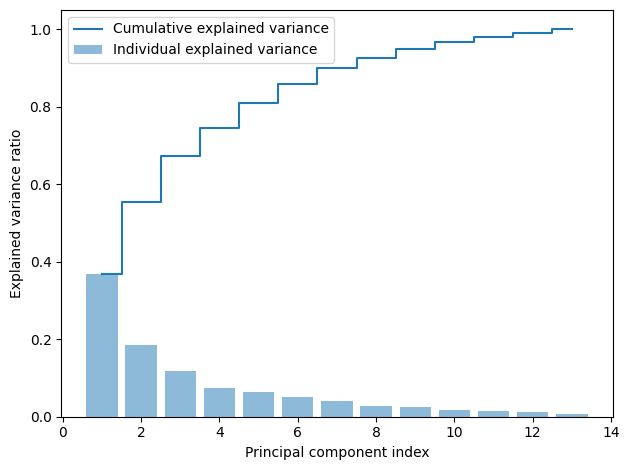

In [ ]:
# variance and explained variance
tot = sum(eigen_vals)
var_exp = [(i / tot) for i in sorted(eigen_vals, reverse=True)]
cum_var_exp = np.cumsum(var_exp)
import matplotlib.pyplot as plt


plt.bar(range(1, 14), var_exp, alpha=0.5, align='center',
        label='Individual explained variance')
plt.step(range(1, 14), cum_var_exp, where='mid',
         label='Cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

Nhận xét: 5 thành phần đặc trưng đã chiếm đến 80% phương sai

In [ ]:
# Make a list of (eigenvalue, eigenvector) tuples
eigen_pairs = [(np.abs(eigen_vals[i]), eigen_vecs[:, i])
               for i in range(len(eigen_vals))]

# Sort the (eigenvalue, eigenvector) tuples from high to low
eigen_pairs.sort(key=lambda k: k[0], reverse=True)

In [ ]:
# take two largest-contributing eigenvectors for 2D representation
w = np.hstack((eigen_pairs[0][1][:, np.newaxis],
               eigen_pairs[1][1][:, np.newaxis]))
print('Matrix W:\n', w)

Matrix W:
 [[-0.13724218 -0.50303478]
 [ 0.24724326 -0.16487119]
 [-0.02545159 -0.24456476]
 [ 0.20694508  0.11352904]
 [-0.15436582 -0.28974518]
 [-0.39376952 -0.05080104]
 [-0.41735106  0.02287338]
 [ 0.30572896 -0.09048885]
 [-0.30668347 -0.00835233]
 [ 0.07554066 -0.54977581]
 [-0.32613263  0.20716433]
 [-0.36861022  0.24902536]
 [-0.29669651 -0.38022942]]


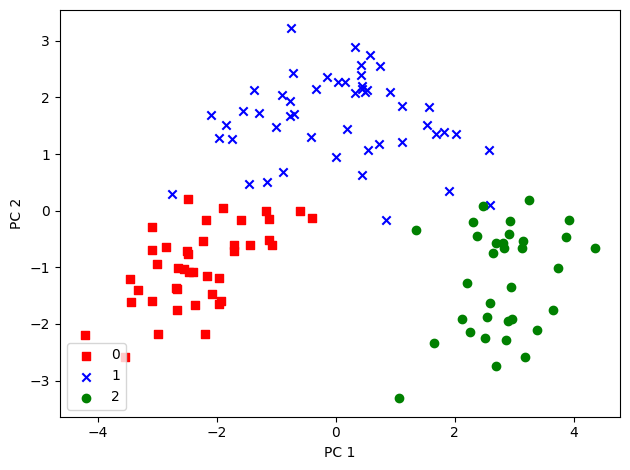

In [ ]:
X_train_std[0].dot(w)

X_train_pca = X_train_std.dot(w)
colors = ['r', 'b', 'g']
markers = ['s', 'x', 'o']

for l, c, m in zip(np.unique(y_train), colors, markers):
    plt.scatter(X_train_pca[y_train == l, 0],
                X_train_pca[y_train == l, 1],
                c=c, label=l, marker=m)

plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

Note:
- PCA is unsupervised (i.e. it doesnt take label information into account).
- Data is more spread throughout the first principle component than the second component.

Triển khai bằng scikt-learn

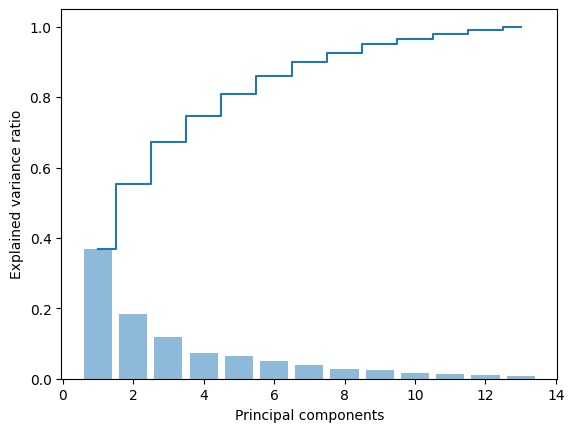

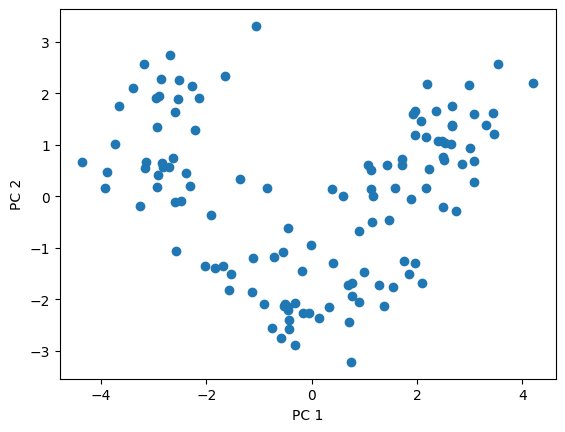

In [ ]:
from sklearn.decomposition import PCA

pca = PCA()
X_train_pca = pca.fit_transform(X_train_std)
pca.explained_variance_ratio_
plt.bar(range(1, 14), pca.explained_variance_ratio_, alpha=0.5, align='center')
plt.step(range(1, 14), np.cumsum(pca.explained_variance_ratio_), where='mid')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')

plt.show()
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1])
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.show()

In [ ]:
from matplotlib.colors import ListedColormap

def plot_decision_regions(X, y, classifier, resolution=0.02):

    # setup marker generator and color map
    markers = ('s', 'X', 'o', '^', 'v') # Changed 'x' to 'X'
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.4, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # plot examples by class
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0],
                    y=X[y == cl, 1],
                    alpha=0.6,
                    color=cmap(idx),
                    edgecolor='black',
                    marker=markers[idx],
                    label=cl)

/tmp/ipykernel_2092/1889389293.py:23: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


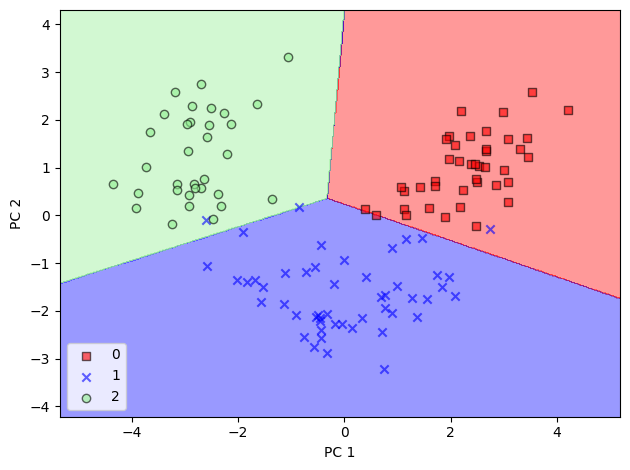

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)

lr = OneVsRestClassifier(LogisticRegression(random_state=1, solver='lbfgs'))
lr.fit(X_train_pca, y_train)

plot_decision_regions(X_train_pca, y_train, classifier=lr)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

In [ ]:
pca = PCA(n_components=None)
X_train_pca = pca.fit_transform(X_train_std)
pca.explained_variance_ratio_

array([0.36951469, 0.18434927, 0.11815159, 0.07334252, 0.06422108,
       0.05051724, 0.03954654, 0.02643918, 0.02389319, 0.01629614,
       0.01380021, 0.01172226, 0.00820609])

# Linear Discriminant Analysis
source: https://machinelearningcoban.com/2017/06/30/lda/

we will implement through the wine dataset

Bước 1: Chuẩn hoá bộ dữ liệu $d$ chiều

Bước 2: Tính toán các vector trung bình (Mean Vectors)

Đầu tiên, chúng ta cần tính vector trung bình cho các đặc trưng của mỗi lớp. Giả sử tập dữ liệu có $c$ lớp, với mỗi lớp $i$, vector trung bình $m_i$ được tính bằng công thức:$$m_i = \frac{1}{n_i} \sum_{x \in D_i} x$$Trong đó:
- $D_i$ là tập hợp các điểm dữ liệu thuộc lớp $i$
- $n_i$ là số lượng mẫu trong lớp $i$.

In [ ]:
np.set_printoptions(precision=4)

mean_vecs = []
for label in range(0, 3):
    mean_vecs.append(np.mean(X_train_std[y_train == label], axis=0))
    print('MV %s: %s\n' % (label, mean_vecs[label - 1]))

MV 0: [ 0.9066 -0.3497  0.3201 -0.7189  0.5056  0.8807  0.9589 -0.5516  0.5416
  0.2338  0.5897  0.6563  1.2075]

MV 1: [ 0.9066 -0.3497  0.3201 -0.7189  0.5056  0.8807  0.9589 -0.5516  0.5416
  0.2338  0.5897  0.6563  1.2075]

MV 2: [-0.8749 -0.2848 -0.3735  0.3157 -0.3848 -0.0433  0.0635 -0.0946  0.0703
 -0.8286  0.3144  0.3608 -0.7253]



Bước 3: Tính toán Ma trận Phân tán (Scatter Matrices)

Để đánh giá khả năng phân tách, LDA sử dụng hai ma trận: Ma trận phân tán trong lớp ($S_W$) và Ma trận phân tán giữa các lớp ($S_B$)

## 2.1 Ma trận phân tán trong lớp (Within-class Scatter Matrix - $S_W$)

Ma trận này đo lường sự phân tán của dữ liệu bên trong từng lớp.$$S_W = \sum_{i=1}^{c} S_i$$Với $S_i$ là ma trận phân tán của riêng lớp $i$:$$S_i = \sum_{x \in D_i} (x - m_i)(x - m_i)^T$$
## 2.2 Ma trận phân tán giữa các lớp (Between-class Scatter Matrix - $S_B$)
Ma trận này đo lường khoảng cách giữa trung bình của các lớp so với trung bình của toàn bộ dữ liệu ($m$).$$S_B = \sum_{i=1}^{c} n_i (m_i - m)(m_i - m)^T$$Trong đó, $m$ là vector trung bình chung của tất cả các mẫu dữ liệu, tính bằng: $m = \frac{1}{n} \sum_{i=1}^{n} x_i$.

In [ ]:
d = X.shape[1]

# S_W
S_W = np.zeros((d, d))
for label, mv in zip(range(3), mean_vecs):
    class_sc_mat = np.zeros((d, d))
    for row in X_train_std[y_train == label]:
        row, mv = row.reshape(d, 1), mv.reshape(d, 1)
        term_dot_shape = (row - mv).dot((row - mv).T).shape
        class_sc_mat += (row - mv).dot((row - mv).T)

    S_W += class_sc_mat

print('Ma trận phân tán trong lớp S_W:\n', S_W)

# S_B
overall_mean = np.mean(X_train_std, axis=0).reshape(d, 1)
S_B = np.zeros((d, d))
for i, mean_vec in enumerate(mean_vecs):
    n = X_train_std[y_train == i].shape[0]
    mean_vec = mean_vec.reshape(d, 1)
    S_B += n * (mean_vec - overall_mean).dot((mean_vec - overall_mean).T)

print('\nMa trận phân tán giữa các lớp S_B:\n', S_B)

Ma trận phân tán trong lớp S_W:
 [[ 5.0722e+01  3.1007e+00 -7.9323e+00 -5.7848e+00 -2.8879e+00  7.8990e+00
   2.4543e+00  9.3932e-01  9.0781e-01  1.5486e+01  7.0293e+00 -1.8659e+00
   4.9370e+00]
 [ 3.1007e+00  9.0179e+01  4.7074e+00  1.4750e+01 -1.0900e+01 -8.8059e-02
   9.7797e-01  8.4547e+00  4.4732e+00 -1.4494e+01 -2.0361e+01  3.5876e+00
  -1.1176e+01]
 [-7.9323e+00  4.7074e+00  1.1189e+02  7.0126e+01  2.2213e+01  1.5505e+01
   1.4856e+01  2.0454e+01 -2.3344e+00  1.3787e+00  5.6585e+00  8.1917e+00
   3.2570e-01]
 [-5.7848e+00  1.4750e+01  7.0126e+01  9.2147e+01  1.2485e+01  6.2091e+00
   6.2783e+00  1.2735e+01 -4.7597e+00 -4.1511e+00  1.1779e+00  1.1633e+01
  -4.5296e+00]
 [-2.8879e+00 -1.0900e+01  2.2213e+01  1.2485e+01  1.0605e+02  1.0950e+01
   5.2875e+00 -2.1136e+01  1.3076e+01  5.9930e+00  8.4568e+00 -5.3128e-01
   1.1845e+01]
 [ 7.8990e+00 -8.8059e-02  1.5505e+01  6.2091e+00  1.0950e+01  5.7194e+01
   2.8971e+01 -7.4850e+00  3.0810e+01  1.5516e+01  6.6816e-01  1.9382e+01
   6

Better: covariance matrix since classes are not equally distributed:

Bước 3: Giải bài toán Trị riêng (Eigenvalue Problem)

Mục tiêu tối ưu của LDA là tìm một ma trận chiếu $W$ sao cho tỷ lệ giữa phương sai giữa các lớp và phương sai trong lớp là lớn nhất:$$J(W) = \frac{\vert{}W^T S_B W\vert{}}{\vert{}W^T S_W W\vert{}}$$Theo đại số tuyến tính, việc tìm cực đại cho biểu thức này tương đương với việc giải bài toán trị riêng cho ma trận $S_W^{-1} S_B$.

In [ ]:
eigen_vals, eigen_vecs = np.linalg.eigh(np.linalg.inv(S_W).dot(S_B))
print('Trị riêng theo thứ tự giảm dần:\n')
for eigen_val in eigen_pairs:
    print(eigen_val[0])

Trị riêng theo thứ tự giảm dần:

11.442268724972408
5.509965223293217
4.880125832844283
2.8827834625842783
2.6807941290470976
1.5034481821677959
0.7924763900814682
0.6887769244394208
0.36252947066172464
0.3031306264909309
0.12443845126204575
0.0780976206072751
0.009724072702195186


In [ ]:
# Tạo danh sách các tuple (trị riêng, vector riêng)
eigen_pairs = [(np.abs(eigen_vals[i]), eigen_vecs[:, i]) for i in range(len(eigen_vals))]

eigen_pairs = sorted(eigen_pairs, key=lambda k: k[0], reverse=True)

# Chọn 2 vector riêng đầu tiên (k=2) để ghép thành ma trận W (13x2)
W = np.hstack((eigen_pairs[0][1][:, np.newaxis].real,
               eigen_pairs[1][1][:, np.newaxis].real))

print('Ma trận chiếu W:\n', W)

Ma trận chiếu W:
 [[-0.1593 -0.1852]
 [ 0.2192  0.2747]
 [-0.0433 -0.0363]
 [ 0.2318  0.2469]
 [-0.0998 -0.1707]
 [-0.2937 -0.6031]
 [-0.6061  0.1619]
 [ 0.0646  0.2725]
 [-0.1028 -0.2062]
 [ 0.2362 -0.3104]
 [-0.1209 -0.1702]
 [-0.3441  0.2136]
 [-0.4514  0.3481]]


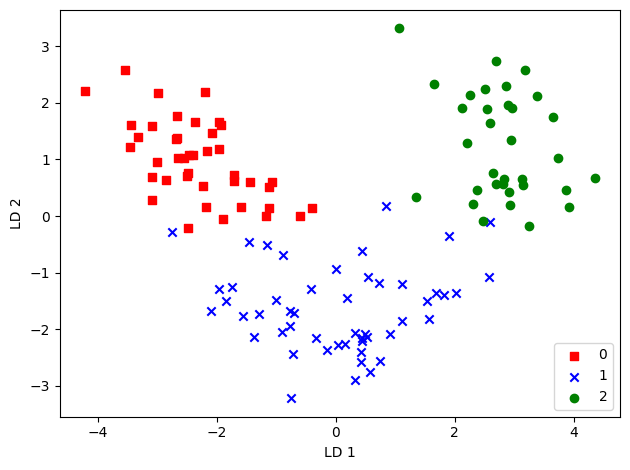

In [ ]:
# trực quan hoá kết quả
X_train_lda = X_train_std.dot(w)
colors = ['r', 'b', 'g']
markers = ['s', 'x', 'o']

for l, c, m in zip(np.unique(y_train), colors, markers):
    plt.scatter(X_train_lda[y_train == l, 0],
                X_train_lda[y_train == l, 1] * (-1),
                c=c, label=l, marker=m)

plt.xlabel('LD 1')
plt.ylabel('LD 2')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2092/1889389293.py:23: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


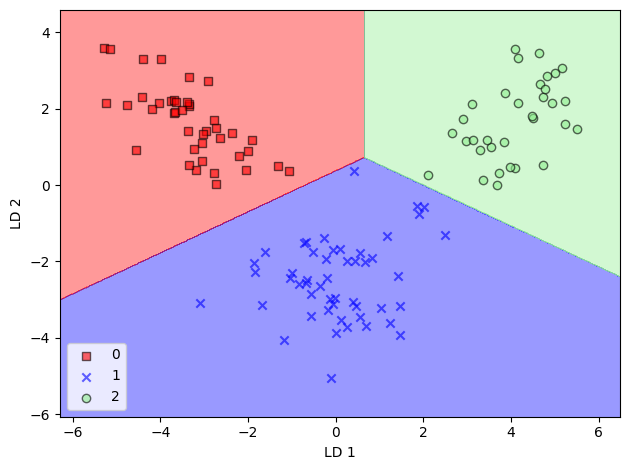

In [ ]:
#LDA implementation through scikit-learn
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

lda = LDA(n_components=2)
X_train_lda = lda.fit_transform(X_train_std, y_train)
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=1, solver='lbfgs') # Removed multi_class='ovr'
lr = lr.fit(X_train_lda, y_train)

plot_decision_regions(X_train_lda, y_train, classifier=lr)
plt.xlabel('LD 1')
plt.ylabel('LD 2')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()